In [ ]:
import sys
from pathlib import Path
# Add project root to sys.path so 'src.*' imports resolve correctly
sys.path.insert(0, str(Path("../..").resolve()))

# Notebook Overview

**Purpose:**
This notebook performs a structured out-of-sample evaluation of previously trained LSTM and xLSTM models across multiple equities, forecast horizons, and feature configurations. It restores the best saved model artifacts per configuration, reproduces the original test-set preprocessing pipeline, computes denormalised test metrics (RMSE and R²), and generates publication-ready comparison figures and tables.

**Inputs:**
- Sentiment-augmented time series CSVs per ticker: `../data/ts_with_sentiment/{TICKER}_ts_with_sentiment.csv` (expects `Close`, optional sentiment features, and the corresponding date index handled by `PrepAndDataLoader`).
- Saved best-model artifacts per ticker and configuration:
  - Checkpoints: `../data/best_models/{TICKER}/{MODEL}_H{H}_F{F}_{TICKER}.pt`
  - Config files: `../data/best_models/{TICKER}/{MODEL}_H{H}_F{F}_{TICKER}.config.json`
- Evaluation configuration parameters:
  - Tick list, feature sets (F=1 vs. F=5), horizons, window size, stride, normalisation method, batch size, global seed.
- Local plotting style settings (dark theme) applied via Matplotlib `rcParams`.

**Outputs:**
- Per-configuration comparison plots (True vs. LSTM vs. xLSTM) saved for each ticker:
  - PDF: `../data/Figures/Plots/{TICKER}/COMPARE_H{H}_F{F}_{TICKER}.pdf`
  - PNG: `../data/Figures/Plots/{TICKER}/COMPARE_H{H}_F{F}_{TICKER}.png`
- Per-ticker result tables (CSV and LaTeX) summarising test RMSE and R²:
  - `../data/Figures/Tables/{TICKER}/results_{TICKER}.csv`
  - `../data/Figures/Tables/{TICKER}/results_{TICKER}.tex`
- Per-ticker Error Reduction (ER) tables quantifying RMSE(LSTM) − RMSE(xLSTM):
  - `../data/Figures/Tables/{TICKER}/er_{TICKER}.csv`
  - `../data/Figures/Tables/{TICKER}/er_{TICKER}.tex`
- Global summary exports across all assets:
  - `../data/Figures/Tables/_global/results_all_assets.csv`
  - `../data/Figures/Tables/_global/results_all_assets.tex`
  - Optional failures log: `../data/Figures/Tables/_global/failures.csv`

**Process Summary:**
For each ticker, the notebook iterates over model types (LSTM, xLSTM), feature sets (price-only vs. price plus sentiment), and horizons. For each configuration it (i) reloads the saved checkpoint and configuration, (ii) reconstructs the test set using the same preprocessing, windowing, stride, and normalisation settings as training, (iii) generates multi-horizon predictions, (iv) denormalises predictions and targets back to the original price level, and (v) computes test RMSE and R² on the denormalised scale. Results are collected into per-ticker and global tables, Error Reduction metrics are computed by aligning LSTM and xLSTM rows, and comparison plots are produced for consistent visual inspection of model performance.

**Workflow Notes:**
- The notebook assumes that saved artifacts exist for every `(ticker, model_type, horizon, n_features)` combination; missing checkpoints or configs are recorded as failures and excluded from plots/tables.
- Denormalisation relies on cached base values produced during `prepare_data_from_prep`; therefore, the normalisation method and preprocessing parameters must remain consistent with the training pipeline.
- Plots are generated for the final horizon step (t+H) when `stride = 1`, enabling a consistent comparison across horizons while preserving chronological alignm


In [2]:
import json
from pathlib import Path
from typing import Dict, Any, List, Literal, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, root_mean_squared_error

import torch

from src.data_prep import PrepAndDataLoader
from src.model_wrapper import Model, set_global_seed

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Info] Using device: {DEVICE}")

[Info] Using device: cpu


In [3]:
import matplotlib as mpl
# %%
# =========================
# Plot style (HHN thesis style)
# =========================
def set_hhn_plot_style() -> None:
    plt.style.use("default")
    mpl.rcParams.update({
        # Fonts & text
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,

        # Lines
        "lines.linewidth": 1.4,
        "lines.markersize": 4,

        # Colors
        "axes.prop_cycle": mpl.cycler(color=[
            "#003366",  # HHN blue
            "#999999",  # neutral gray
            "#0072B2",  # lighter blue
            "#CC0000",  # red accent
            "#56B4E9",  # light blue
        ]),

        # Axes & grid
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#cccccc",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,

        # Background
        "figure.facecolor": "white",
        "axes.facecolor": "white",

        # Legend
        "legend.frameon": False,
        "legend.loc": "best",

        # Savefig
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

set_hhn_plot_style()


In [4]:
# %%
# =========================
# Global configuration (must match training)
# =========================

TICKERS: List[str] = ["AAPL", "DIS", "IBM", "INTC", "JNJ", "JPM", "KO", "MSFT", "NKE", "V"]

DATA_DIR = Path("../../data/ts_with_sentiment")
FILE_PATTERN = "{ticker}_ts_with_sentiment.csv"
TARGET_COL: str = "Close"
TRAIN_SPLIT: float = 0.6
VAL_SPLIT: float = 0.2

FEATURE_SETS: Dict[str, List[str]] = {
    "price_only": ["Close"],  # F1
    "price_plus_sentiment": ["Close", "pos_mean", "neut_mean", "neg_mean", "news_count"],  # F5
}
FEATURE_KEYS_ORDER = ["price_only", "price_plus_sentiment"]

WINDOW_SIZE: int = 60
HORIZONS: List[int] = [1, 3, 5, 10, 15]
STRIDE: int = 1

NORMALISE: bool = True
NORM_METHOD: Literal["percentage", "minmax"] = "percentage"

BATCH_SIZE: int = 128
MODEL_TYPES: List[str] = ["LSTM", "xLSTM"]

GLOBAL_SEED: int = 42

BEST_MODELS_ROOT = Path("../../data/best_models")
FIG_PLOTS_ROOT = Path("../../data/results/plots")

# New output root for CSVs
CSV_OUT_ROOT = Path("../../data/results/csv")
CSV_OUT_ROOT.mkdir(parents=True, exist_ok=True)

FIG_PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

print("[Info] Configuration loaded.")


[Info] Configuration loaded.


In [5]:
# %%
# =========================
# Helpers
# =========================

def ensure_reproducible(seed: int) -> None:
    set_global_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_base_name(model_type: str, horizon: int, n_features: int, ticker: str) -> str:
    return f"{model_type}_H{horizon}_F{n_features}_{ticker}"


def load_saved_artifacts(ticker: str, model_type: str, horizon: int, n_features: int) -> Tuple[Path, Dict[str, Any]]:
    model_dir = BEST_MODELS_ROOT / ticker
    name = make_base_name(model_type, horizon, n_features, ticker)

    ckpt = model_dir / f"{name}.pt"
    cfgp = model_dir / f"{name}.config.json"

    if not ckpt.is_file():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt}")
    if not cfgp.is_file():
        raise FileNotFoundError(f"Missing config: {cfgp}")

    with open(cfgp, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return ckpt, cfg


def prepare_test_data(ticker: str, feature_cols: List[str], horizon: int) -> Dict[str, Any]:
    csv_path = DATA_DIR / FILE_PATTERN.format(ticker=ticker)
    if not csv_path.is_file():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

    prep = PrepAndDataLoader(
        filename=str(csv_path),
        training_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        cols=feature_cols,
        target_col=TARGET_COL,
    )

    tmp_model = Model()
    _, _, _, _, X_te, y_te = tmp_model.prepare_data_from_prep(
        prep,
        normalise=NORMALISE,
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        norm_method=NORM_METHOD,
        stride=STRIDE,
        verbose=0,
    )

    dates_te = prep.get_prediction_dates(
        "test",
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        stride=STRIDE,
    )  # [N, H]

    baseT_te = tmp_model._cache.get("baseT_te", None)

    return {"prep": prep, "X_te": X_te, "y_te": y_te, "dates_te": dates_te, "baseT_te": baseT_te}


def denormalise_to_level(
    prep: PrepAndDataLoader,
    y_true_scaled: np.ndarray,   # [N, H, 1]
    y_pred_scaled: np.ndarray,   # [N, H]
    baseT_te: Optional[np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    y_pred_scaled_3d = y_pred_scaled[..., None]  # [N, H, 1]
    y_true_scaled_3d = y_true_scaled             # [N, H, 1]

    if not NORMALISE:
        return y_true_scaled.squeeze(-1), y_pred_scaled

    if NORM_METHOD == "percentage":
        if baseT_te is None:
            raise ValueError("baseT_te is required for percentage normalisation.")

        y_pred_level = prep.denormalise(
            y_pred_scaled_3d, method="percentage", base_values=baseT_te, normalise=True
        ).squeeze(-1)
        y_true_level = prep.denormalise(
            y_true_scaled_3d, method="percentage", base_values=baseT_te, normalise=True
        ).squeeze(-1)
        return y_true_level, y_pred_level

    if NORM_METHOD == "minmax":
        y_pred_level = prep.denormalise(
            y_pred_scaled_3d, method="minmax", base_values=None, normalise=True
        ).squeeze(-1)
        y_true_level = prep.denormalise(
            y_true_scaled_3d, method="minmax", base_values=None, normalise=True
        ).squeeze(-1)
        return y_true_level, y_pred_level

    raise ValueError(f"Unknown NORM_METHOD={NORM_METHOD}")


def compute_metrics_level(y_true_level: np.ndarray, y_pred_level: np.ndarray) -> Tuple[float, float]:
    y_true_flat = y_true_level.reshape(-1)
    y_pred_flat = y_pred_level.reshape(-1)
    rmse = float(root_mean_squared_error(y_true_flat, y_pred_flat))
    r2 = float(r2_score(y_true_flat, y_pred_flat))
    return rmse, r2


def predict_saved_model(
    ticker: str,
    model_type: str,
    horizon: int,
    feature_set_name: str,
    feature_cols: List[str],
) -> Dict[str, Any]:
    n_features = len(feature_cols)

    data = prepare_test_data(ticker, feature_cols, horizon)
    prep = data["prep"]
    X_te = data["X_te"]
    y_te = data["y_te"]
    dates_te = data["dates_te"]
    baseT_te = data["baseT_te"]

    ckpt_path, cfg = load_saved_artifacts(ticker, model_type, horizon, n_features)

    # Ensure evaluation uses current global settings
    cfg = dict(cfg)
    cfg["window_size"] = int(WINDOW_SIZE)
    cfg["horizon"] = int(horizon)
    cfg["n_features"] = int(X_te.shape[-1])

    ensure_reproducible(GLOBAL_SEED)

    m = Model()
    m.build(config=cfg, model_type=model_type)
    m.load(str(ckpt_path))

    y_pred_scaled = m.predict_multi_horizon(X_te, batch_size=BATCH_SIZE, verbose=0)
    y_true_level, y_pred_level = denormalise_to_level(prep, y_te, y_pred_scaled, baseT_te)

    rmse, r2 = compute_metrics_level(y_true_level, y_pred_level)

    return {
        "asset": ticker,
        "model": model_type,
        "feature": feature_set_name,
        "n_features": n_features,
        "h": horizon,
        "rmse_level": rmse,
        "r2_level": r2,

        "dates_te": dates_te,
        "y_true_level": y_true_level,
        "y_pred_level": y_pred_level,
    }


In [6]:
# %%
# =========================
# Plotting (HHN style)
# =========================

def plot_compare_predictions(
    ticker: str,
    horizon: int,
    n_features: int,
    dates_te: np.ndarray,        # [N, H]
    y_true_level: np.ndarray,    # [N, H]
    y_lstm_level: np.ndarray,    # [N, H]
    y_xlstm_level: np.ndarray,   # [N, H]
    rmse_lstm: float,
    rmse_xlstm: float,
    r2_lstm: float,
    r2_xlstm: float,
    save_pdf: Path,
    save_png: Path,
) -> None:

    h_idx = horizon - 1
    dates = dates_te[:, h_idx]

    plt.figure(figsize=(12, 5))

    plt.plot(dates, y_true_level[:, h_idx], label="True", linewidth=2.3)

    plt.plot(
        dates, y_lstm_level[:, h_idx],
        label=f"LSTM (RMSE={rmse_lstm:.3f}, R²={r2_lstm:.3f})",
        linestyle="--", linewidth=1.9
    )

    plt.plot(
        dates, y_xlstm_level[:, h_idx],
        label=f"xLSTM (RMSE={rmse_xlstm:.3f}, R²={r2_xlstm:.3f})",
        linestyle="--", linewidth=1.9
    )

    plt.title(f"{ticker} – Prediction Comparison | H={horizon} | F={n_features} – TEST")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    save_pdf.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_pdf, format="pdf")
    plt.savefig(save_png, format="png", dpi=300)
    plt.close()


In [7]:
# %%
# =========================
# Batch evaluation over all assets/models/features/horizons
# Produces:
# - df_master (level metrics + ER)
# - multiple CSVs
# =========================

ensure_reproducible(GLOBAL_SEED)

all_rows: List[Dict[str, Any]] = []
failures: List[Dict[str, Any]] = []

total_jobs = len(TICKERS) * len(MODEL_TYPES) * len(FEATURE_SETS) * len(HORIZONS)
job_i = 0

for ticker in TICKERS:
    for model_type in MODEL_TYPES:
        for feature_set_name in FEATURE_KEYS_ORDER:
            feature_cols = FEATURE_SETS[feature_set_name]
            for horizon in HORIZONS:
                job_i += 1
                tag = f"{ticker} | {model_type} | {feature_set_name} | H={horizon}"
                print(f"\n[{job_i}/{total_jobs}] {tag}")

                try:
                    res = predict_saved_model(
                        ticker=ticker,
                        model_type=model_type,
                        horizon=horizon,
                        feature_set_name=feature_set_name,
                        feature_cols=feature_cols,
                    )

                    # Keep only scalar reporting fields for the master table
                    all_rows.append({
                        "asset": res["asset"],
                        "model": res["model"],
                        "feature": res["feature"],
                        "n_features": res["n_features"],
                        "h": res["h"],
                        "rmse_level": res["rmse_level"],
                        "r2_level": res["r2_level"],
                    })

                except Exception as e:
                    print(f"[FAIL] {tag}: {e}")
                    failures.append({
                        "asset": ticker,
                        "model": model_type,
                        "feature": feature_set_name,
                        "n_features": len(feature_cols),
                        "h": horizon,
                        "error": str(e),
                    })

df_raw = pd.DataFrame(all_rows).sort_values(
    by=["asset", "feature", "h", "model"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

df_fail = pd.DataFrame(failures)

print("\n=========================")
print(f"[Done] Successful rows: {len(df_raw)}")
print(f"[Done] Failures:       {len(df_fail)}")

df_raw.head(10)


[1/200] AAPL | LSTM | price_only | H=1
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F1_AAPL.pt

[2/200] AAPL | LSTM | price_only | H=3
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  LSTM layers=4
  Trainable params: 463,747
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H3_F1_AAPL.pt

[3/200] AAPL | LSTM | price_only | H=5
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=5
  LSTM layers=1
  Trainable params: 17,477
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H5_F1_AAPL.pt

[4/200] AAPL | LSTM | price_only | H=10
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=10
  LSTM layers=1
  Trainable params: 68,362
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H10_F1_AAPL.pt

[5/200] AAPL | LSTM | price_only | H=15
[Model] LSTM 

,asset,model,feature,n_features,h,rmse_level,r2_level
0,AAPL,LSTM,price_only,1,1,2.931257,0.991299
1,AAPL,xLSTM,price_only,1,1,2.963846,0.991104
2,AAPL,LSTM,price_only,1,3,4.205925,0.982046
3,AAPL,xLSTM,price_only,1,3,4.148166,0.982536
4,AAPL,LSTM,price_only,1,5,5.092690,0.973614
5,AAPL,xLSTM,price_only,1,5,5.054941,0.974004
6,AAPL,LSTM,price_only,1,10,6.980503,0.950283
7,AAPL,xLSTM,price_only,1,10,6.844843,0.952197
8,AAPL,LSTM,price_only,1,15,9.086556,0.915568
9,AAPL,xLSTM,price_only,1,15,8.434042,0.927259


In [8]:
# %%
# =========================
# Build master table + ER (Error Reduction) and save CSVs
# =========================

def build_master_with_er(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Returns df_master with ER columns merged into each row:
    - er_rmse_level = RMSE(LSTM) - RMSE(xLSTM) for same (asset, feature, h)
    - er_r2_level   = R²(xLSTM) - R²(LSTM) for same (asset, feature, h)
    """
    key_cols = ["asset", "feature", "h"]

    df_l = df_raw[df_raw["model"] == "LSTM"][key_cols + ["rmse_level", "r2_level"]].rename(
        columns={"rmse_level": "rmse_lstm", "r2_level": "r2_lstm"}
    )
    df_x = df_raw[df_raw["model"] == "xLSTM"][key_cols + ["rmse_level", "r2_level"]].rename(
        columns={"rmse_level": "rmse_xlstm", "r2_level": "r2_xlstm"}
    )

    df_er = df_l.merge(df_x, on=key_cols, how="inner")
    df_er["er_rmse_level"] = df_er["rmse_lstm"] - df_er["rmse_xlstm"]
    df_er["er_r2_level"] = df_er["r2_xlstm"] - df_er["r2_lstm"]

    df_master = df_raw.merge(df_er[key_cols + ["er_rmse_level", "er_r2_level"]], on=key_cols, how="left")
    df_master = df_master.sort_values(["asset", "feature", "h", "model"]).reset_index(drop=True)
    return df_master


def save_thesis_csvs(df_master: pd.DataFrame, out_root: Path) -> Dict[str, Path]:
    """
    Saves the CSV set you described.
    Returns dict of name -> path.
    """
    out_root.mkdir(parents=True, exist_ok=True)
    saved: Dict[str, Path] = {}

    # ---- Master (single values / base for everything)
    p = out_root / "results_master_level_with_er.csv"
    df_master.to_csv(p, index=False)
    saved["master"] = p

    # ---- Architecture comparison
    arch_mean_by_model = (
        df_master.groupby("model")[["rmse_level", "r2_level"]]
        .mean()
        .reset_index()
        .sort_values("model")
    )
    p = out_root / "arch_mean_by_model.csv"
    arch_mean_by_model.to_csv(p, index=False)
    saved["arch_mean_by_model"] = p

    arch_mean_by_model_h = (
        df_master.groupby(["model", "h"])[["rmse_level", "r2_level"]]
        .mean()
        .reset_index()
        .sort_values(["model", "h"])
    )
    p = out_root / "arch_mean_by_model_and_h.csv"
    arch_mean_by_model_h.to_csv(p, index=False)
    saved["arch_mean_by_model_and_h"] = p

    # ---- Modality (F1 vs F5)
    feature_map = {"price_only": "F1", "price_plus_sentiment": "F5"}
    dfm = df_master.copy()
    dfm["F"] = dfm["feature"].map(feature_map).fillna(dfm["feature"])

    modal_single = dfm[dfm["F"].isin(["F1", "F5"])].copy()
    p = out_root / "modal_single_F1_F5_by_model_h.csv"
    modal_single.sort_values(["asset", "model", "F", "h"]).to_csv(p, index=False)
    saved["modal_single_F1_F5_by_model_h"] = p

    modal_mean_by_model_F = (
        dfm[dfm["F"].isin(["F1", "F5"])]
        .groupby(["model", "F"])[["rmse_level", "r2_level"]]
        .mean()
        .reset_index()
        .sort_values(["model", "F"])
    )
    p = out_root / "modal_mean_by_model_and_F.csv"
    modal_mean_by_model_F.to_csv(p, index=False)
    saved["modal_mean_by_model_and_F"] = p

    # Sentiment effect deltas (F5 - F1) per asset/model/h
    pivot_rmse = dfm.pivot_table(values="rmse_level", index=["asset", "model", "h"], columns="F", aggfunc="mean").reset_index()
    pivot_r2   = dfm.pivot_table(values="r2_level",   index=["asset", "model", "h"], columns="F", aggfunc="mean").reset_index()

    rmse_eff = pivot_rmse.copy()
    rmse_eff["delta_rmse_F5_minus_F1"] = rmse_eff.get("F5") - rmse_eff.get("F1")

    r2_eff = pivot_r2.copy()
    r2_eff["delta_r2_F5_minus_F1"] = r2_eff.get("F5") - r2_eff.get("F1")

    eff = rmse_eff[["asset", "model", "h", "delta_rmse_F5_minus_F1"]].merge(
        r2_eff[["asset", "model", "h", "delta_r2_F5_minus_F1"]],
        on=["asset", "model", "h"],
        how="inner"
    ).sort_values(["asset", "model", "h"]).reset_index(drop=True)

    p = out_root / "modal_sentiment_effect_deltas_per_asset_model_h.csv"
    eff.to_csv(p, index=False)
    saved["modal_sentiment_effect_deltas_per_asset_model_h"] = p

    sentiment_effect_mean_by_model = (
        eff.groupby("model")[["delta_rmse_F5_minus_F1", "delta_r2_F5_minus_F1"]]
        .mean()
        .reset_index()
        .sort_values("model")
    )
    p = out_root / "modal_sentiment_effect_mean_by_model.csv"
    sentiment_effect_mean_by_model.to_csv(p, index=False)
    saved["modal_sentiment_effect_mean_by_model"] = p

    # ---- Horizon influence
    h_mean_over_all_models = (
        df_master.groupby("h")[["rmse_level", "r2_level"]]
        .mean()
        .reset_index()
        .sort_values("h")
    )
    p = out_root / "h_mean_over_all_models.csv"
    h_mean_over_all_models.to_csv(p, index=False)
    saved["h_mean_over_all_models"] = p

    # ---- Global / overview pivots
    pivot_rmse_model = df_master.pivot_table(
        values="rmse_level",
        index=["asset", "feature", "h"],
        columns="model",
        aggfunc="mean"
    ).reset_index()

    p = out_root / "pivot_rmse_level_model_columns.csv"
    pivot_rmse_model.to_csv(p, index=False)
    saved["pivot_rmse_level_model_columns"] = p

    heat_lstm = df_master[df_master["model"] == "LSTM"].pivot_table(
        values="rmse_level",
        index="feature",
        columns="h",
        aggfunc="mean"
    ).reset_index()

    p = out_root / "heat_rmse_level_LSTM_feature_by_h.csv"
    heat_lstm.to_csv(p, index=False)
    saved["heat_rmse_level_LSTM_feature_by_h"] = p

    heat_xlstm = df_master[df_master["model"] == "xLSTM"].pivot_table(
        values="rmse_level",
        index="feature",
        columns="h",
        aggfunc="mean"
    ).reset_index()

    p = out_root / "heat_rmse_level_xLSTM_feature_by_h.csv"
    heat_xlstm.to_csv(p, index=False)
    saved["heat_rmse_level_xLSTM_feature_by_h"] = p

    return saved


df_master = build_master_with_er(df_raw)

#saved_paths = save_thesis_csvs(df_master, CSV_OUT_ROOT)

print("\n[Saved CSVs]")
#for k, v in saved_paths.items():
 #   print(f"- {k:45s} -> {v}")

if not df_fail.empty:
    p = CSV_OUT_ROOT / "failures.csv"
    df_fail.to_csv(p, index=False)
    print(f"\n[Saved] failures -> {p}")

df_master.head(10)



[Saved CSVs]


,asset,model,feature,n_features,h,rmse_level,r2_level,er_rmse_level,er_r2_level
0,AAPL,LSTM,price_only,1,1,2.931257,0.991299,-0.032590,-0.000195
1,AAPL,xLSTM,price_only,1,1,2.963846,0.991104,-0.032590,-0.000195
2,AAPL,LSTM,price_only,1,3,4.205925,0.982046,0.057760,0.000490
3,AAPL,xLSTM,price_only,1,3,4.148166,0.982536,0.057760,0.000490
4,AAPL,LSTM,price_only,1,5,5.092690,0.973614,0.037748,0.000390
5,AAPL,xLSTM,price_only,1,5,5.054941,0.974004,0.037748,0.000390
6,AAPL,LSTM,price_only,1,10,6.980503,0.950283,0.135660,0.001914
7,AAPL,xLSTM,price_only,1,10,6.844843,0.952197,0.135660,0.001914
8,AAPL,LSTM,price_only,1,15,9.086556,0.915568,0.652514,0.011691
9,AAPL,xLSTM,price_only,1,15,8.434042,0.927259,0.652514,0.011691


In [8]:
# %%
# =========================
# Generate compare plots for all assets/configs
# This is compute-heavy;
# =========================

make_all_compare_plots = True

if make_all_compare_plots:
    for ticker in TICKERS:
        plot_dir = FIG_PLOTS_ROOT / ticker
        plot_dir.mkdir(parents=True, exist_ok=True)

        for feature_set_name in FEATURE_KEYS_ORDER:
            feature_cols = FEATURE_SETS[feature_set_name]
            n_features = len(feature_cols)

            for horizon in HORIZONS:
                try:
                    lstm_res  = predict_saved_model(ticker, "LSTM",  horizon, feature_set_name, feature_cols)
                    xlstm_res = predict_saved_model(ticker, "xLSTM", horizon, feature_set_name, feature_cols)

                    name = f"COMPARE_H{horizon}_F{n_features}_{ticker}"
                    plot_pdf = plot_dir / f"{name}.pdf"
                    plot_png = plot_dir / f"{name}.png"

                    plot_compare_predictions(
                        ticker=ticker,
                        horizon=horizon,
                        n_features=n_features,
                        dates_te=lstm_res["dates_te"],
                        y_true_level=lstm_res["y_true_level"],
                        y_lstm_level=lstm_res["y_pred_level"],
                        y_xlstm_level=xlstm_res["y_pred_level"],
                        rmse_lstm=lstm_res["rmse_level"],
                        rmse_xlstm=xlstm_res["rmse_level"],
                        r2_lstm=lstm_res["r2_level"],
                        r2_xlstm=xlstm_res["r2_level"],
                        save_pdf=plot_pdf,
                        save_png=plot_png,
                    )

                except Exception as e:
                    print(f"[WARN] Plot failed for {ticker} {feature_set_name} H={horizon}: {e}")

    print("[Done] Compare plots generated.")


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  xLSTM blocks=2, sLSTM at=[1]
  Trainable params: 55,811
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H1_F1_AAPL.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  LSTM layers=4
  Trainable params: 463,747
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H3_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 346,467
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H3_F1_AAPL.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=5
  LSTM layers=1
  Trainable params: 17,477
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H5

In [8]:
# Map feature-set names to thesis notation
FEATURE_MAP = {
    "price_only": "F1",
    "price_plus_sentiment": "F5",
}

df_feat = df_master.copy()
df_feat["F"] = df_feat["feature"].map(FEATURE_MAP).fillna(df_feat["feature"])

# -------------------------------------------------
# 1) Mean RMSE / R² per (Feature-Set × Horizon),
#    averaged over BOTH models and all assets
# -------------------------------------------------
agg_F_h = (
    df_feat[df_feat["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])[["rmse_level", "r2_level"]]
    .mean()
    .reset_index()
    .sort_values(["F", "h"])
)

p_fh = CSV_OUT_ROOT / "agg_rmse_r2_by_F_and_h.csv"
#agg_F_h.to_csv(p_fh, index=False)

display(agg_F_h)
print(f"[Saved] {p_fh}")

# -------------------------------------------------
# 2) Wide pivots (nice for heatmaps / quick plotting)
#    Rows: Feature-Set (F1/F5)
#    Cols: Horizon (H)
# -------------------------------------------------
pivot_rmse_F_h = agg_F_h.pivot(index="F", columns="h", values="rmse_level").reset_index()
pivot_r2_F_h   = agg_F_h.pivot(index="F", columns="h", values="r2_level").reset_index()

p_piv_rmse = CSV_OUT_ROOT / "pivot_rmse_by_F_and_h.csv"
p_piv_r2   = CSV_OUT_ROOT / "pivot_r2_by_F_and_h.csv"

#pivot_rmse_F_h.to_csv(p_piv_rmse, index=False)
#pivot_r2_F_h.to_csv(p_piv_r2, index=False)

display(pivot_rmse_F_h)
display(pivot_r2_F_h)

print(f"[Saved] {p_piv_rmse}")
print(f"[Saved] {p_piv_r2}")

NameError: name 'CSV_OUT' is not defined

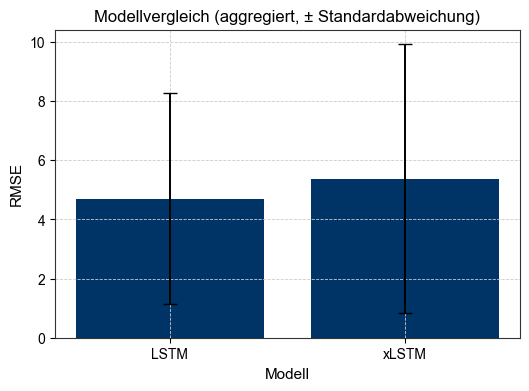

In [9]:
# -------------------------------------------------
# Modellvergleich (aggregiert) mit Standardabweichung
# -------------------------------------------------
agg_model_mean = (
    df_master
    .groupby("model")["rmse_level"]
    .mean()
)

agg_model_std = (
    df_master
    .groupby("model")["rmse_level"]
    .std()
)

plt.figure(figsize=(6, 4))
plt.bar(
    agg_model_mean.index,
    agg_model_mean.values,
    yerr=agg_model_std.values,
    capsize=5
)
plt.xlabel("Modell")
plt.ylabel("RMSE")
plt.title("Modellvergleich (aggregiert, ± Standardabweichung)")
plt.show()



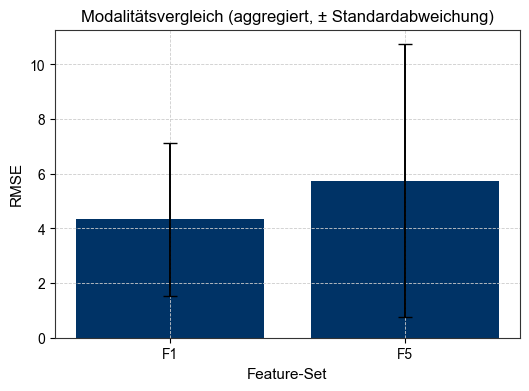

In [10]:
# -------------------------------------------------
# Modalitätsvergleich (aggregiert) mit Standardabweichung
# -------------------------------------------------
feature_map = {"price_only": "F1", "price_plus_sentiment": "F5"}

df_tmp = df_master.copy()
df_tmp["F"] = df_tmp["feature"].map(feature_map)

agg_F_mean = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby("F")["rmse_level"]
    .mean()
)

agg_F_std = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby("F")["rmse_level"]
    .std()
)

plt.figure(figsize=(6, 4))
plt.bar(
    agg_F_mean.index,
    agg_F_mean.values,
    yerr=agg_F_std.values,
    capsize=5
)
plt.xlabel("Feature-Set")
plt.ylabel("RMSE")
plt.title("Modalitätsvergleich (aggregiert, ± Standardabweichung)")
plt.show()




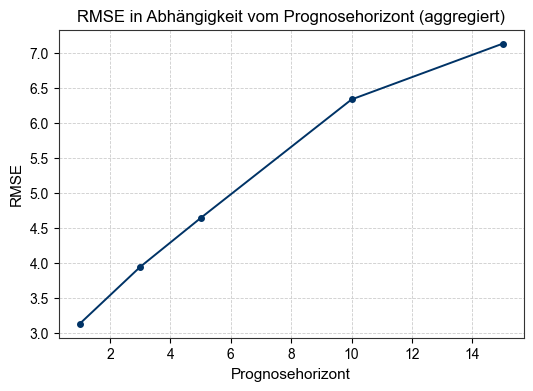

In [12]:
# -------------------------------------------------
# Plot 3 – Prognosehorizont (einzel aggregiert)
# -------------------------------------------------
agg_h = (
    df_master
    .groupby("h")[["rmse_level"]]
    .mean()
    .reset_index()
    .sort_values("h")
)

plt.figure(figsize=(6, 4))
plt.plot(agg_h["h"], agg_h["rmse_level"], marker="o")
plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("RMSE in Abhängigkeit vom Prognosehorizont (aggregiert)")
plt.show()


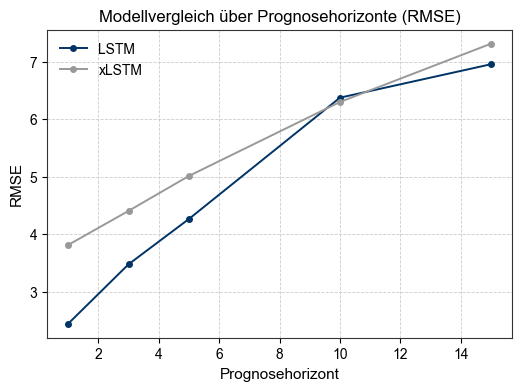

In [16]:
# -------------------------------------------------
# Plot 4a – Modell × Horizont (RMSE, ohne Standardabweichung)
# Aggregiert über alle Aktien und Feature-Sets
# -------------------------------------------------
agg_model_h_rmse = (
    df_master
    .groupby(["model", "h"])["rmse_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for model in MODEL_TYPES:
    sub = agg_model_h_rmse[agg_model_h_rmse["model"] == model]
    plt.plot(
        sub["h"],
        sub["rmse_level"],
        marker="o",
        label=model
    )

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Modellvergleich über Prognosehorizonte (RMSE)")
plt.legend()
plt.show()


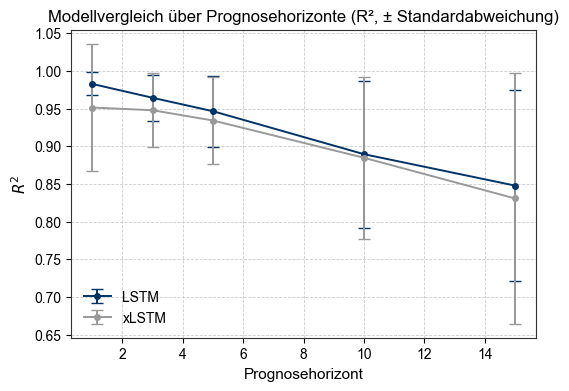

In [17]:
# -------------------------------------------------
# Plot 4b – Modell × Horizont (R², ± Standardabweichung)
# Aggregiert über alle Aktien und Feature-Sets
# -------------------------------------------------
agg_model_h_r2_mean = (
    df_master
    .groupby(["model", "h"])["r2_level"]
    .mean()
    .reset_index()
)

agg_model_h_r2_std = (
    df_master
    .groupby(["model", "h"])["r2_level"]
    .std()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for model in MODEL_TYPES:
    mean_sub = agg_model_h_r2_mean[agg_model_h_r2_mean["model"] == model]
    std_sub = agg_model_h_r2_std[agg_model_h_r2_std["model"] == model]

    plt.errorbar(
        mean_sub["h"],
        mean_sub["r2_level"],
        yerr=std_sub["r2_level"],
        marker="o",
        capsize=4,
        label=model
    )

plt.xlabel("Prognosehorizont")
plt.ylabel(r"$R^2$")
plt.title("Modellvergleich über Prognosehorizonte (R², ± Standardabweichung)")
plt.legend()
plt.show()


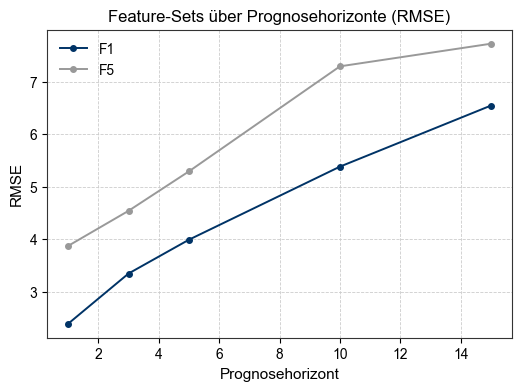

In [18]:
# -------------------------------------------------
# Plot 5a – Modalität × Horizont (RMSE, ohne Standardabweichung)
# Aggregiert über alle Aktien und Modelle
# -------------------------------------------------
feature_map = {"price_only": "F1", "price_plus_sentiment": "F5"}

df_tmp = df_master.copy()
df_tmp["F"] = df_tmp["feature"].map(feature_map)

agg_F_h_rmse = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["rmse_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for F in ["F1", "F5"]:
    sub = agg_F_h_rmse[agg_F_h_rmse["F"] == F]
    plt.plot(
        sub["h"],
        sub["rmse_level"],
        marker="o",
        label=F
    )

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Feature-Sets über Prognosehorizonte (RMSE)")
plt.legend()
plt.show()


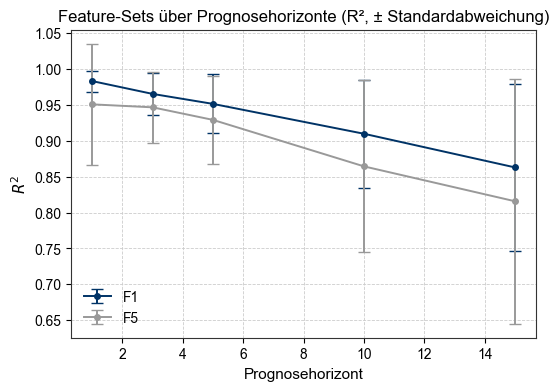

In [19]:
# -------------------------------------------------
# Plot 5b – Modalität × Horizont (R², ± Standardabweichung)
# Aggregiert über alle Aktien und Modelle
# -------------------------------------------------
agg_F_h_r2_mean = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["r2_level"]
    .mean()
    .reset_index()
)

agg_F_h_r2_std = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["r2_level"]
    .std()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for F in ["F1", "F5"]:
    mean_sub = agg_F_h_r2_mean[agg_F_h_r2_mean["F"] == F]
    std_sub = agg_F_h_r2_std[agg_F_h_r2_std["F"] == F]

    plt.errorbar(
        mean_sub["h"],
        mean_sub["r2_level"],
        yerr=std_sub["r2_level"],
        marker="o",
        capsize=4,
        label=F
    )

plt.xlabel("Prognosehorizont")
plt.ylabel(r"$R^2$")
plt.title("Feature-Sets über Prognosehorizonte (R², ± Standardabweichung)")
plt.legend()
plt.show()


In [9]:
lstm_res  = predict_saved_model("AAPL", "LSTM",  horizon, "price_only", FEATURE_SETS["price_only"])
xlstm_res = predict_saved_model("AAPL", "xLSTM", horizon, "price_only", FEATURE_SETS["price_only"])


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  LSTM layers=4
  Trainable params: 117,967
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H15_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  xLSTM blocks=8, sLSTM at=[7]
  Trainable params: 175,871
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H15_F1_AAPL.pt


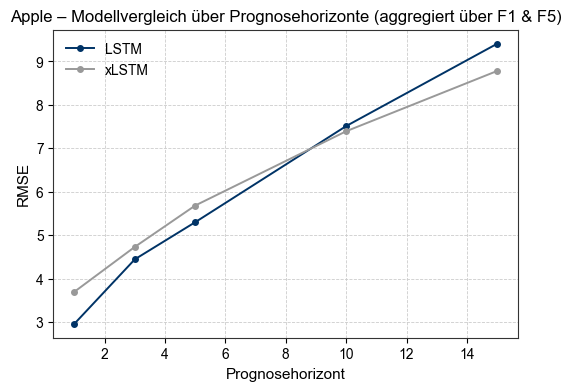

In [28]:
# -------------------------------------------------
# Apple – Modellvergleich über Prognosehorizonte
# Aggregiert über F1 + F5
# -------------------------------------------------
df_aapl = df_master[df_master["asset"] == "AAPL"]

agg_aapl_model_h = (
    df_aapl
    .groupby(["model", "h"])[["rmse_level"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for model in MODEL_TYPES:
    sub = agg_aapl_model_h[agg_aapl_model_h["model"] == model]
    plt.plot(sub["h"], sub["rmse_level"], marker="o", label=model)

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Apple – Modellvergleich über Prognosehorizonte (aggregiert über F1 & F5)")
plt.legend()
plt.show()


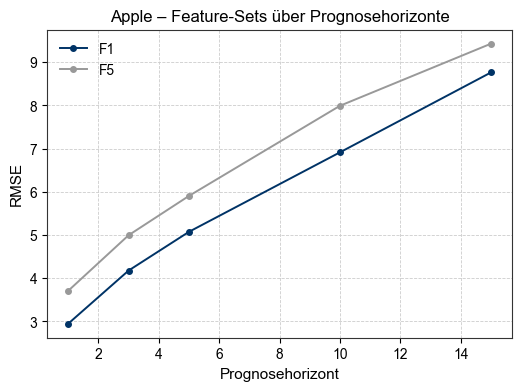

In [19]:
# -------------------------------------------------
# Apple – Feature-Sets über Prognosehorizonte
# -------------------------------------------------
feature_map = {"price_only": "F1", "price_plus_sentiment": "F5"}

df_aapl = df_master[df_master["asset"] == "AAPL"].copy()
df_aapl["F"] = df_aapl["feature"].map(feature_map)

agg_aapl_F_h = (
    df_aapl[df_aapl["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])[["rmse_level"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

for F in ["F1", "F5"]:
    sub = agg_aapl_F_h[agg_aapl_F_h["F"] == F]
    plt.plot(sub["h"], sub["rmse_level"], marker="o", label=F)

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Apple – Feature-Sets über Prognosehorizonte")
plt.legend()
plt.show()


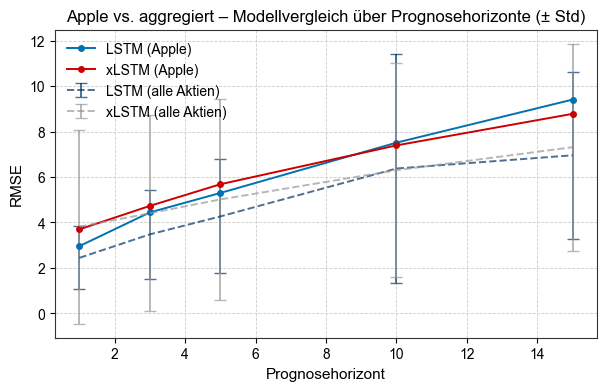

In [13]:
# -------------------------------------------------
# Apple vs. Aggregiert – Modellvergleich über Horizonte
# Aggregiert über F1 + F5
# -------------------------------------------------
agg_all_model_h = (
    df_master
    .groupby(["model", "h"])[["rmse_level"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

# Aggregiert (alle Aktien)
for model in MODEL_TYPES:
    sub = agg_all_model_h[agg_all_model_h["model"] == model]
    plt.plot(
        sub["h"], sub["rmse_level"],
        linestyle="--", alpha=0.7,
        label=f"{model} (alle Aktien)"
    )

# Apple
for model in MODEL_TYPES:
    sub = agg_aapl_model_h[agg_aapl_model_h["model"] == model]
    plt.plot(
        sub["h"], sub["rmse_level"],
        marker="o",
        label=f"{model} (Apple)"
    )

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Apple vs. aggregiert – Modellvergleich über Prognosehorizonte (F1 & F5)")
plt.legend()
plt.show()


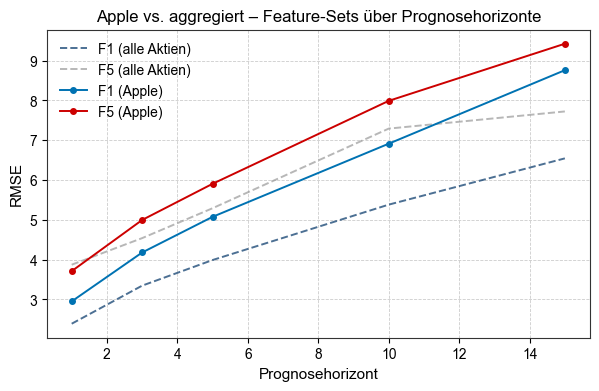

In [21]:
# -------------------------------------------------
# Apple vs. Aggregiert – Feature-Sets über Horizonte
# -------------------------------------------------
df_all = df_master.copy()
df_all["F"] = df_all["feature"].map(feature_map)

agg_all_F_h = (
    df_all[df_all["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])[["rmse_level"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

# Aggregiert
for F in ["F1", "F5"]:
    sub = agg_all_F_h[agg_all_F_h["F"] == F]
    plt.plot(
        sub["h"], sub["rmse_level"],
        linestyle="--", alpha=0.7,
        label=f"{F} (alle Aktien)"
    )

# Apple
for F in ["F1", "F5"]:
    sub = agg_aapl_F_h[agg_aapl_F_h["F"] == F]
    plt.plot(
        sub["h"], sub["rmse_level"],
        marker="o",
        label=f"{F} (Apple)"
    )

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Apple vs. aggregiert – Feature-Sets über Prognosehorizonte")
plt.legend()
plt.show()


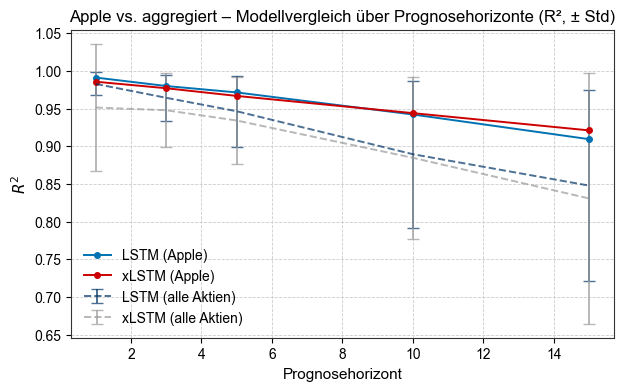

In [14]:
# -------------------------------------------------
# Apple vs. Aggregiert – Modellvergleich über Horizonte (R²)
# Aggregiert über F1 + F5
# Fehlerbalken nur für aggregierte Werte
# -------------------------------------------------

# Aggregiert (alle Aktien)
agg_all_mean_r2 = (
    df_master
    .groupby(["model", "h"])["r2_level"]
    .mean()
    .reset_index()
)

agg_all_std_r2 = (
    df_master
    .groupby(["model", "h"])["r2_level"]
    .std()
    .reset_index()
)

# Apple-only
df_aapl = df_master[df_master["asset"] == "AAPL"]

agg_aapl_r2 = (
    df_aapl
    .groupby(["model", "h"])["r2_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

# Aggregierte Linien mit Fehlerbalken
for model in MODEL_TYPES:
    mean_sub = agg_all_mean_r2[agg_all_mean_r2["model"] == model]
    std_sub = agg_all_std_r2[agg_all_std_r2["model"] == model]

    plt.errorbar(
        mean_sub["h"],
        mean_sub["r2_level"],
        yerr=std_sub["r2_level"],
        linestyle="--",
        capsize=4,
        alpha=0.7,
        label=f"{model} (alle Aktien)"
    )

# Apple-Linien ohne Fehlerbalken
for model in MODEL_TYPES:
    sub = agg_aapl_r2[agg_aapl_r2["model"] == model]
    plt.plot(
        sub["h"],
        sub["r2_level"],
        marker="o",
        label=f"{model} (Apple)"
    )

plt.xlabel("Prognosehorizont")
plt.ylabel(r"$R^2$")
plt.title("Apple vs. aggregiert – Modellvergleich über Prognosehorizonte (R², ± Std)")
plt.legend()
plt.show()


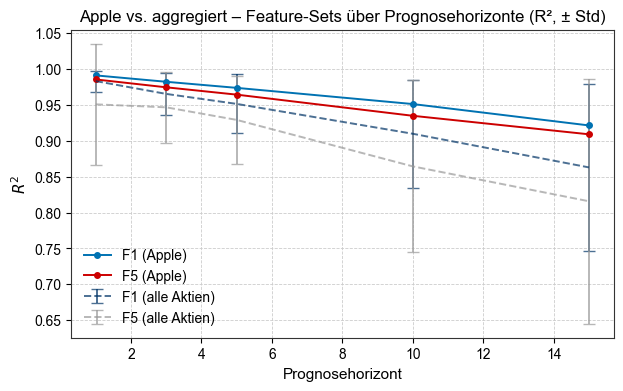

In [15]:
# -------------------------------------------------
# Apple vs. Aggregiert – Feature-Sets über Horizonte (R²)
# Fehlerbalken nur für aggregierte Werte
# -------------------------------------------------

feature_map = {"price_only": "F1", "price_plus_sentiment": "F5"}

df_tmp = df_master.copy()
df_tmp["F"] = df_tmp["feature"].map(feature_map)

# Aggregiert (alle Aktien, beide Modelle)
agg_all_F_mean_r2 = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["r2_level"]
    .mean()
    .reset_index()
)

agg_all_F_std_r2 = (
    df_tmp[df_tmp["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["r2_level"]
    .std()
    .reset_index()
)

# Apple-only
df_aapl = df_tmp[df_tmp["asset"] == "AAPL"]

agg_aapl_F_r2 = (
    df_aapl[df_aapl["F"].isin(["F1", "F5"])]
    .groupby(["F", "h"])["r2_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

# Aggregierte Linien mit Fehlerbalken
for F in ["F1", "F5"]:
    mean_sub = agg_all_F_mean_r2[agg_all_F_mean_r2["F"] == F]
    std_sub = agg_all_F_std_r2[agg_all_F_std_r2["F"] == F]

    plt.errorbar(
        mean_sub["h"],
        mean_sub["r2_level"],
        yerr=std_sub["r2_level"],
        linestyle="--",
        capsize=4,
        alpha=0.7,
        label=f"{F} (alle Aktien)"
    )

# Apple-Linien ohne Fehlerbalken
for F in ["F1", "F5"]:
    sub = agg_aapl_F_r2[agg_aapl_F_r2["F"] == F]
    plt.plot(
        sub["h"],
        sub["r2_level"],
        marker="o",
        label=f"{F} (Apple)"
    )

plt.xlabel("Prognosehorizont")
plt.ylabel(r"$R^2$")
plt.title("Apple vs. aggregiert – Feature-Sets über Prognosehorizonte (R², ± Std)")
plt.legend()
plt.show()


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  xLSTM blocks=2, sLSTM at=[1]
  Trainable params: 55,811
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H1_F1_AAPL.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 51,521
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F5_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=96 | horizon=1
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 372,889
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H1_F5_AAPL.pt


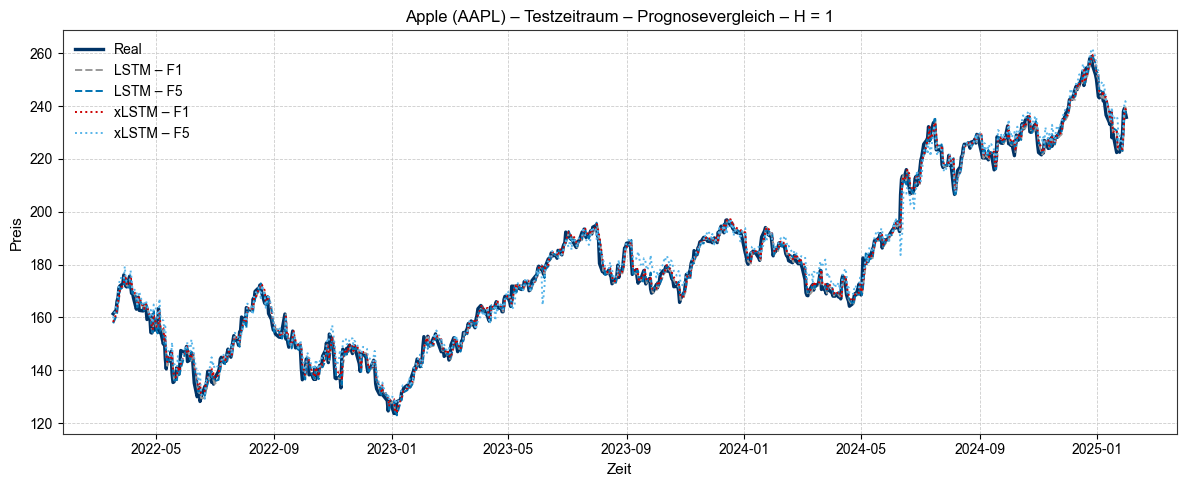

In [31]:
# -------------------------------------------------
# Apple – Zeitreihenvergleich – H = 1
# Modelle: LSTM / xLSTM
# Feature-Sets: F1 / F5
# -------------------------------------------------
horizon = 1
h_idx = horizon - 1

# F1
lstm_f1 = predict_saved_model("AAPL", "LSTM", horizon, "price_only", FEATURE_SETS["price_only"])
xlstm_f1 = predict_saved_model("AAPL", "xLSTM", horizon, "price_only", FEATURE_SETS["price_only"])

# F5
lstm_f5 = predict_saved_model("AAPL", "LSTM", horizon, "price_plus_sentiment", FEATURE_SETS["price_plus_sentiment"])
xlstm_f5 = predict_saved_model("AAPL", "xLSTM", horizon, "price_plus_sentiment", FEATURE_SETS["price_plus_sentiment"])

dates = lstm_f1["dates_te"][:, h_idx]

plt.figure(figsize=(12, 5))

# Ground truth
plt.plot(
    dates,
    lstm_f1["y_true_level"][:, h_idx],
    label="Real",
    linewidth=2.4
)

# Predictions
plt.plot(dates, lstm_f1["y_pred_level"][:, h_idx], label="LSTM – F1", linestyle="--")
plt.plot(dates, lstm_f5["y_pred_level"][:, h_idx], label="LSTM – F5", linestyle="--")

plt.plot(dates, xlstm_f1["y_pred_level"][:, h_idx], label="xLSTM – F1", linestyle=":")
plt.plot(dates, xlstm_f5["y_pred_level"][:, h_idx], label="xLSTM – F5", linestyle=":")

plt.xlabel("Zeit")
plt.ylabel("Preis")
plt.title("Apple (AAPL) – Testzeitraum – Prognosevergleich – H = 1")
plt.legend()
plt.tight_layout()
plt.show()


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  LSTM layers=4
  Trainable params: 117,967
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H15_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=15
  xLSTM blocks=8, sLSTM at=[7]
  Trainable params: 175,871
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H15_F1_AAPL.pt
[Model] LSTM compiled:
  Input: seq_len=60, features=5 | hidden=128 | horizon=15
  LSTM layers=4
  Trainable params: 467,343
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H15_F5_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=64 | horizon=15
  xLSTM blocks=6, sLSTM at=[5]
  Trainable params: 180,535
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H15_F5_AAPL.pt


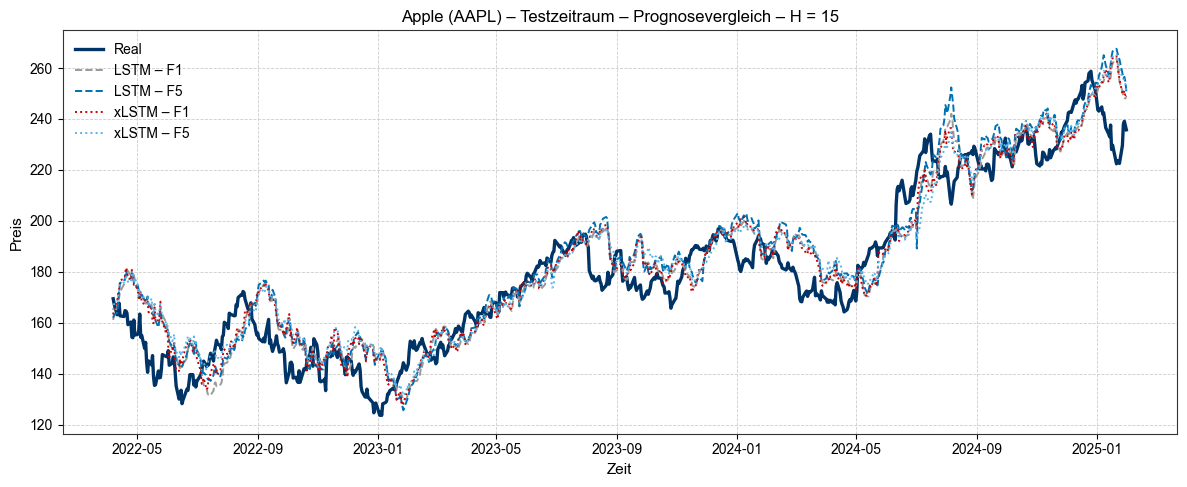

In [30]:
# -------------------------------------------------
# Apple – Zeitreihenvergleich – H = 15
# Modelle: LSTM / xLSTM
# Feature-Sets: F1 / F5
# -------------------------------------------------
horizon = 15
h_idx = horizon - 1

# F1
lstm_f1  = predict_saved_model("AAPL", "LSTM",  horizon, "price_only", FEATURE_SETS["price_only"])
xlstm_f1 = predict_saved_model("AAPL", "xLSTM", horizon, "price_only", FEATURE_SETS["price_only"])

# F5
lstm_f5  = predict_saved_model("AAPL", "LSTM",  horizon, "price_plus_sentiment", FEATURE_SETS["price_plus_sentiment"])
xlstm_f5 = predict_saved_model("AAPL", "xLSTM", horizon, "price_plus_sentiment", FEATURE_SETS["price_plus_sentiment"])

dates = lstm_f1["dates_te"][:, h_idx]

plt.figure(figsize=(12, 5))

# Ground truth
plt.plot(
    dates,
    lstm_f1["y_true_level"][:, h_idx],
    label="Real",
    linewidth=2.4
)

# Predictions
plt.plot(dates, lstm_f1["y_pred_level"][:, h_idx], label="LSTM – F1", linestyle="--")
plt.plot(dates, lstm_f5["y_pred_level"][:, h_idx], label="LSTM – F5", linestyle="--")

plt.plot(dates, xlstm_f1["y_pred_level"][:, h_idx], label="xLSTM – F1", linestyle=":")
plt.plot(dates, xlstm_f5["y_pred_level"][:, h_idx], label="xLSTM – F5", linestyle=":")

plt.xlabel("Zeit")
plt.ylabel("Preis")
plt.title("Apple (AAPL) – Testzeitraum – Prognosevergleich – H = 15")
plt.legend()
plt.tight_layout()
plt.show()


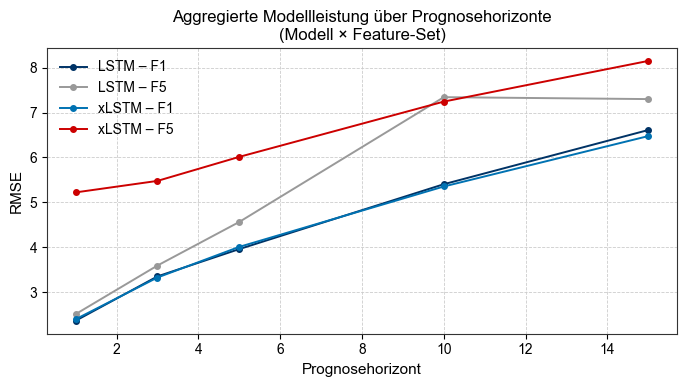

In [11]:
# -------------------------------------------------
# Aggregierter Plot:
# Prognosehorizont × Modell × Feature-Set (RMSE)
# -------------------------------------------------

FEATURE_MAP = {
    "price_only": "F1",
    "price_plus_sentiment": "F5",
}

df_plot = df_master.copy()
df_plot["F"] = df_plot["feature"].map(FEATURE_MAP)

agg = (
    df_plot[df_plot["F"].isin(["F1", "F5"])]
    .groupby(["h", "model", "F"])["rmse_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

for model in MODEL_TYPES:
    for F in ["F1", "F5"]:
        sub = agg[(agg["model"] == model) & (agg["F"] == F)]
        plt.plot(
            sub["h"],
            sub["rmse_level"],
            marker="o",
            label=f"{model} – {F}"
        )

plt.xlabel("Prognosehorizont")
plt.ylabel("RMSE")
plt.title("Aggregierte Modellleistung über Prognosehorizonte\n(Modell × Feature-Set)")
plt.legend()
plt.tight_layout()
plt.show()
